<a href="https://colab.research.google.com/github/nomcebosandisiwe5-oss/Ubuntu-Micro-Manufacturing-Planner/blob/main/Prediction_Material_Cost_For_Specific_Welding_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
  #Core
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [3]:
# data evaluation
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

In [4]:
# preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

In [5]:
# models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model  import Ridge

In [6]:
 #metrics
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    r2_score, mean_absolute_percentage_error
)


In [7]:
# model persistence
import joblib
import os

In [8]:
df_raw = pd.read_csv("/content/drive/MyDrive/welding_pricing_dataset.csv")

In [9]:
print('=== Head (5 rows) ===')
display(df_raw.head())

print('\n=== Data types & non-null counts ===')
df_raw.info()

print('\n=== Descriptive Statistics ===')
display(df_raw.describe().T.style.background_gradient(cmap='Blues'))
print(df_raw.columns)


#Categorical Breakdown
print("Material value counts:")
display(df_raw['Material'].value_counts().to_frame())

df_raw['Complexity_score'] = df_raw['Thickness_m'] * df_raw['Length_m']

print('\nComplexity_score range:', df_raw['Complexity_score'].min(), '-', df_raw['Complexity_score'].max())


=== Head (5 rows) ===


,ID,Material,Type,Shape,Size_m,Thickness_m,Length_m,Price_ZAR,Price_per_meter
0,1,Steel,MIG,Flat,100,5,10,2500,250
1,2,Steel,TIG,Circular,150,8,15,4200,280
2,3,Aluminum,MIG,Flat,80,4,8,1800,225
3,4,Stainless Steel,TIG,Box,120,6,12,5400,450
4,5,Steel,Stick,Flat,100,10,20,8000,400



=== Data types & non-null counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005 entries, 0 to 1004
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ID               1005 non-null   int64 
 1   Material         1005 non-null   object
 2   Type             1005 non-null   object
 3   Shape            1005 non-null   object
 4   Size_m           1005 non-null   int64 
 5   Thickness_m      1005 non-null   int64 
 6   Length_m         1005 non-null   int64 
 7   Price_ZAR        1005 non-null   int64 
 8   Price_per_meter  1005 non-null   int64 
dtypes: int64(6), object(3)
memory usage: 70.8+ KB

=== Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max
ID,1005.000000,503.000000,290.262812,1.000000,252.000000,503.000000,754.000000,1005.000000
Size_m,1005.000000,117.059701,24.792695,75.000000,95.000000,115.000000,135.000000,180.000000
Thickness_m,1005.000000,6.601990,2.192616,3.000000,5.000000,6.000000,8.000000,12.000000
Length_m,1005.000000,14.538308,3.572496,8.000000,11.000000,14.000000,17.000000,23.000000
Price_ZAR,1005.000000,5602.422886,2726.162025,1575.000000,2750.000000,5915.000000,8000.000000,11500.000000
Price_per_meter,1005.000000,365.991045,122.525137,175.000000,240.000000,390.000000,480.000000,640.000000


Index(['ID', 'Material', 'Type', 'Shape', 'Size_m', 'Thickness_m', 'Length_m',
       'Price_ZAR', 'Price_per_meter'],
      dtype='object')
Material value counts:


,count
Material,
Steel,503
Aluminum,251
Stainless Steel,251



Complexity_score range: 24 - 264


In [10]:
#Missing Values
df = df_raw.copy()
missing = df.isnull().sum()
print('Missing values per column:')
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else ' No missing values found')


#Duplicate rows
dupes = df.duplicated().sum()
print(f'\nDuplicate rows: {dupes}')
if dupes > 0:
    df = df.drop_duplicates()
    print(f'  Removed {dupes} duplicate(s). New shape: {df.shape}')


#Categorical feature
le = LabelEncoder()
df['Material_Encoded'] = le.fit_transform(df['Material'])
print('\nMaterial encoding map:', dict(zip(le.classes_, le.transform(le.classes_))))

print('\nCleaned dataset shape:', df.shape)

Missing values per column:
Missing values per column:
 No missing values found

Duplicate rows: 0

Material encoding map: {'Aluminum': np.int64(0), 'Stainless Steel': np.int64(1), 'Steel': np.int64(2)}

Cleaned dataset shape: (1005, 11)


In [14]:
#Numeric range checks
TARGET = 'Price_ZAR'
df_raw["Complexity_score"] = df_raw['Thickness_m'] * df_raw['Length_m']

checks = {
    'Complexity_core 1-10'  : df_raw['Complexity_score'].between(1, 10).all(),
    'Thickness_m > 0'       : (df_raw['Thickness_m'] > 0).all(),
    'Length_m > 0'          : (df_raw['Length_m'] > 0).all(),
    f'{TARGET} > 0'         : (df_raw[TARGET] > 0).all(),
}

print(checks)


# Outlier detection via IQR
print('\nOutliers detected (IQR method):')
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
for col in numeric_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    if n_out:
        print(f' CHECK {col}: {n_out} outlier(s)')
    else:
        print(f' CHECK {col}: no outliers')

{'Complexity_core 1-10': np.False_, 'Thickness_m > 0': np.True_, 'Length_m > 0': np.True_, 'Price_ZAR > 0': np.True_}

Outliers detected (IQR method):
 CHECK ID: no outliers
 CHECK Size_m: no outliers
 CHECK Thickness_m: no outliers
 CHECK Length_m: no outliers
 CHECK Price_ZAR: no outliers
 CHECK Price_per_meter: no outliers
 CHECK Complexity_score: no outliers
 CHECK Material_Encoded: no outliers


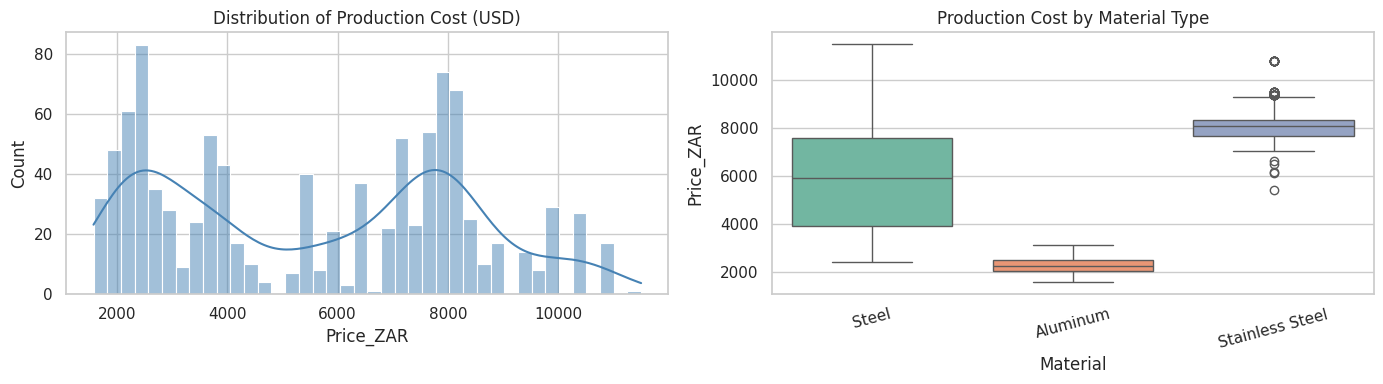

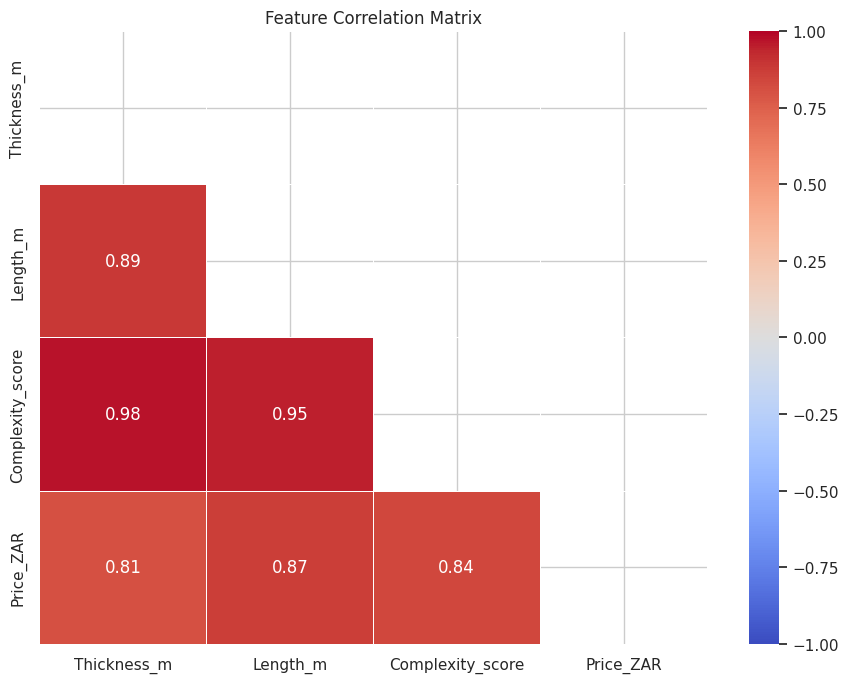

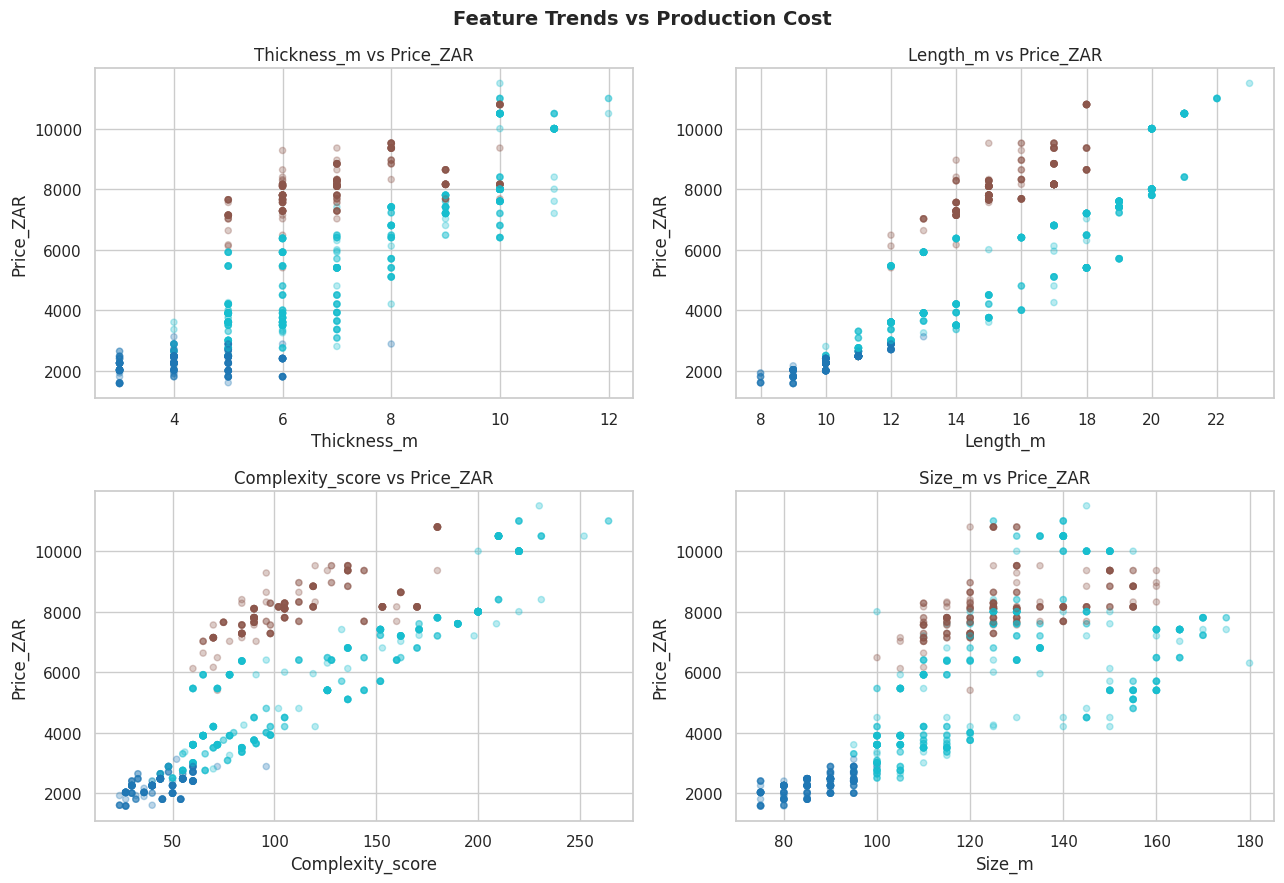

In [15]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df[TARGET], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Production Cost (USD)')

sns.boxplot(x='Material', y=TARGET, data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Production Cost by Material Type')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


# Correlation heatmap
df_raw['Complexity_score'] = df_raw['Thickness_m'] * df_raw['Length_m']

corr_cols = ['Thickness_m', 'Length_m', 'Complexity_score', 'Price_ZAR']
plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(df_raw[corr_cols].corr(), dtype=bool))
sns.heatmap(df_raw[corr_cols].corr(), annot=True, fmt='.2f', mask=mask,
            cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Scatter trends
df_raw['Complexity_score'] = df_raw['Thickness_m'] * df_raw['Length_m']
features_to_plot = ['Thickness_m', 'Length_m', 'Complexity_score', 'Size_m']
TARGET = 'Price_ZAR'

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, feat in zip(axes, features_to_plot):
    ax.scatter(df_raw[feat], df_raw[TARGET], alpha=0.3, s=20, c=df_raw['Material'].astype('category').cat.codes, cmap='tab10')
    ax.set_xlabel(feat)
    ax.set_ylabel(TARGET)
    ax.set_title(f'{feat} vs {TARGET}')

plt.suptitle('Feature Trends vs Production Cost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03_scatter_trends.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
df_raw['Complexity_score'] = df_raw['Thickness_m'] * df_raw['Length_m']
FEATURES = ['Thickness_m', 'Length_m', 'Complexity_score','Size_m']

X = df_raw[FEATURES].values
y = df_raw[TARGET].values

#  80 / 20 split (stratify is not available for regression, so we use random_state)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Standard scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train set : {X_train_s.shape[0]:>4} samples')
print(f'Test  set : {X_test_s.shape[0]:>4} samples')
print(f'Features  : {len(FEATURES)} → {FEATURES}')

Train set :  804 samples
Test  set :  201 samples
Features  : 4 → ['Thickness_m', 'Length_m', 'Complexity_score', 'Size_m']


In [17]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, scaled=True):
    """Train, predict, and return a metrics dict."""
    Xtr = X_tr if scaled else X_train
    Xte = X_te if scaled else X_test

    model.fit(X_tr, y_tr)
    y_pred = model.predict(Xte)

    cv = cross_val_score(model, Xtr, y_tr, cv=5,
                         scoring='r2', n_jobs=-1)
    return {
        'Model'       : name,
        'R² Test'     : round(r2_score(y_te, y_pred), 4),
        'MAE'         : round(mean_absolute_error(y_te, y_pred), 2),
        'RMSE'        : round(np.sqrt(mean_squared_error(y_te, y_pred)), 2),
        'MAPE (%)'    : round(mean_absolute_percentage_error(y_te, y_pred)*100, 2),
        'CV R² mean'  : round(cv.mean(), 4),
        'CV R² std'   : round(cv.std(), 4),
        'y_pred'      : y_pred,
        'object'      : model,
    }

    # Define models

rf  = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
gb  = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                max_depth=4, random_state=42)
rid = Ridge(alpha=1.0)

# Train and evaluate
results = [
    evaluate_model('Random Forest',        rf,  X_train_s, y_train, X_test_s, y_test),
    evaluate_model('Gradient Boosting',    gb,  X_train_s, y_train, X_test_s, y_test),
    evaluate_model('Ridge Regression',     rid, X_train_s, y_train, X_test_s, y_test),
]

# Summary table
metrics_df = pd.DataFrame(results).drop(columns=['y_pred', 'object'])
display(metrics_df.style
        .background_gradient(subset=['R² Test','CV R² mean'], cmap='Greens')
        .background_gradient(subset=['MAE','RMSE','MAPE (%)'],  cmap='Reds_r')
        .set_caption('Model Comparison — Test Set'))

,Model,R² Test,MAE,RMSE,MAPE (%),CV R² mean,CV R² std
0,Random Forest,0.901200,482.680000,866.650000,9.500000,0.873000,0.015200
1,Gradient Boosting,0.901900,537.800000,863.890000,10.500000,0.873800,0.015300
2,Ridge Regression,0.785900,1083.280000,1276.180000,21.750000,0.757900,0.023100


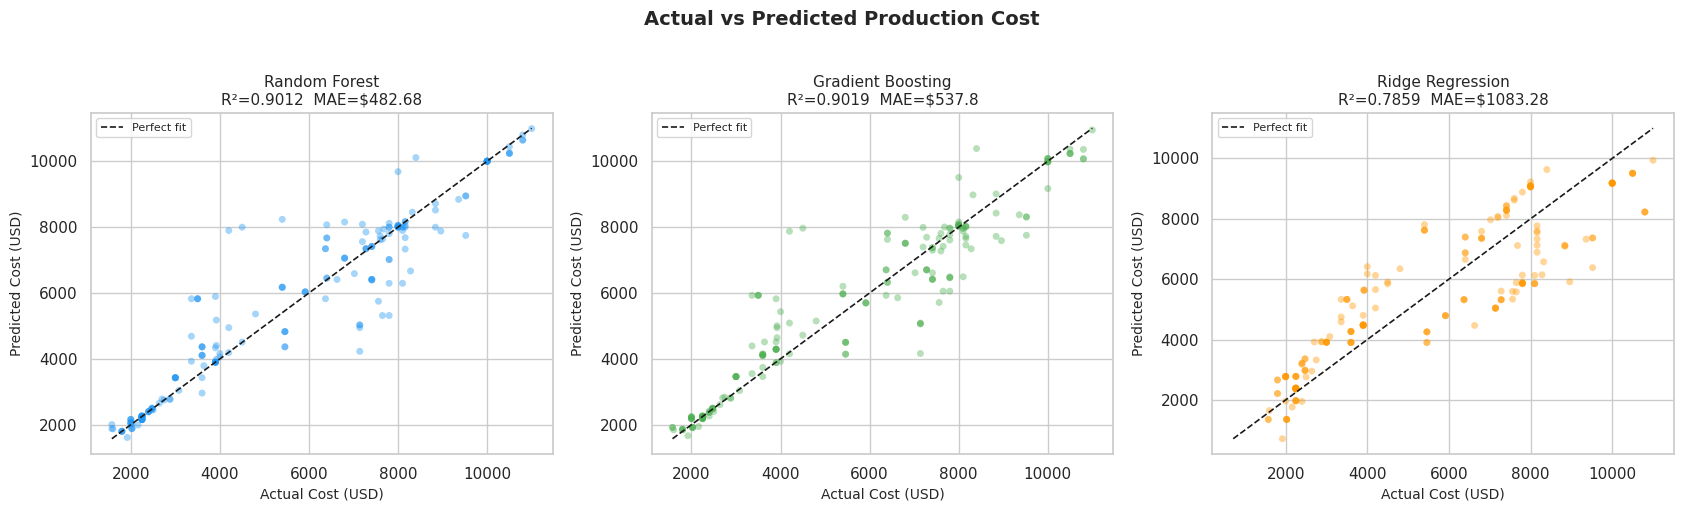

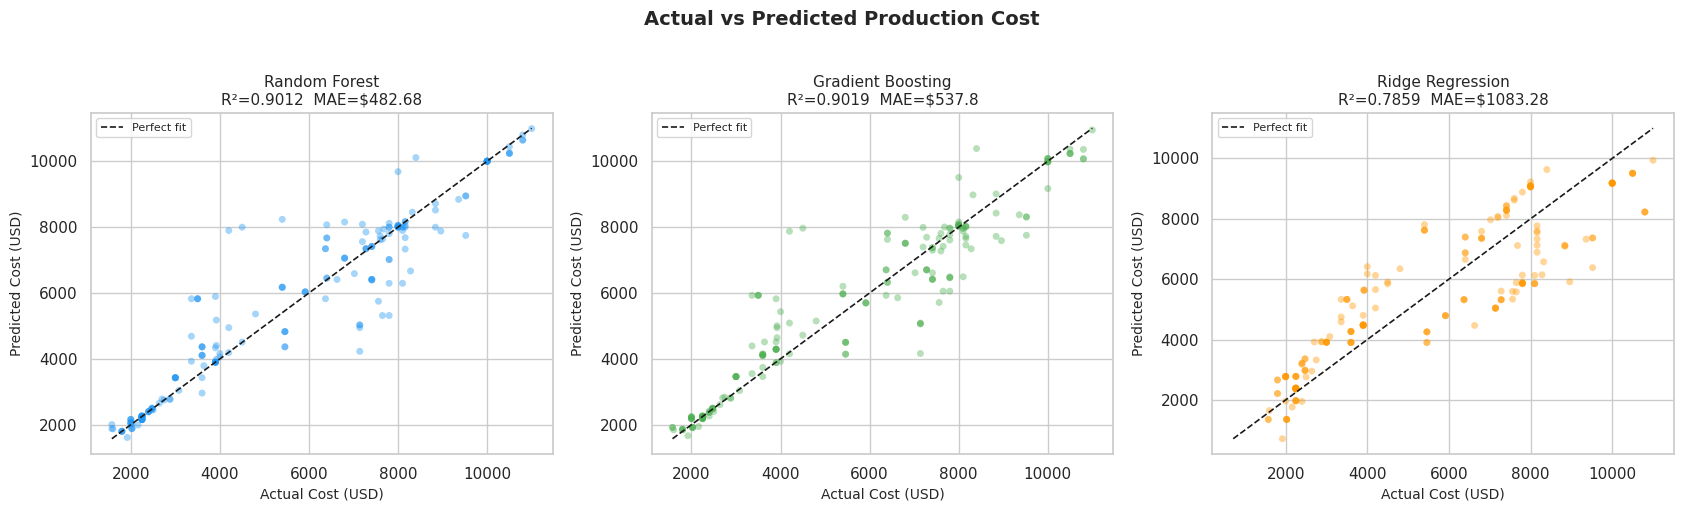

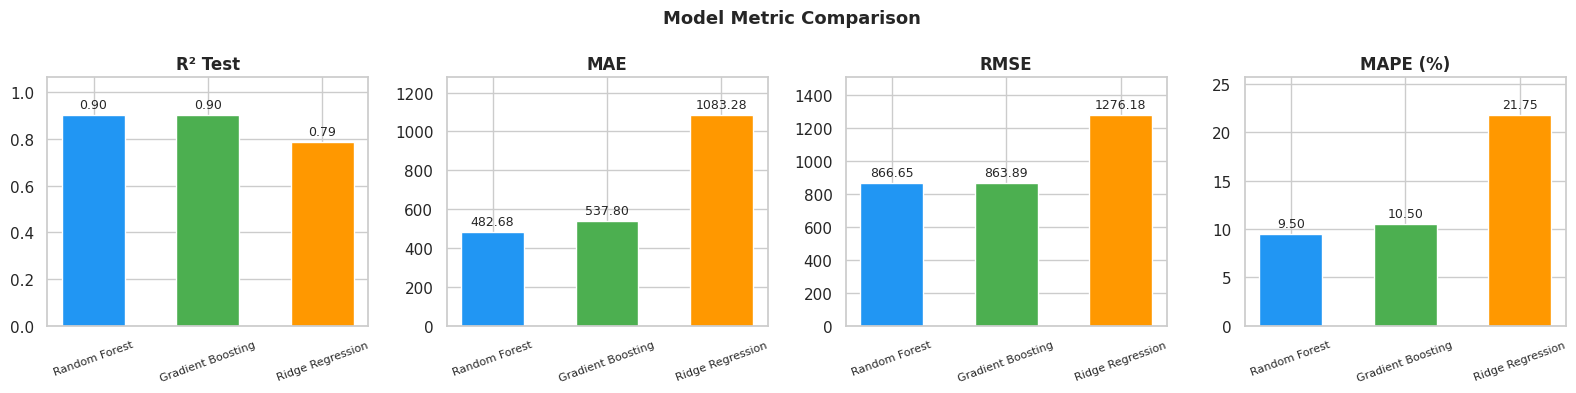

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

colors = ['#2196F3', '#4CAF50', '#FF9800']

for ax, res, color in zip(axes, results, colors):
    y_pred = res['y_pred']

    ax.scatter(y_test, y_pred, alpha=0.4, s=25, color=color, edgecolors='none')

    lims = [min(y_test.min(), y_pred.min()),
            max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1.2, label='Perfect fit')

    ax.set_xlabel('Actual Cost (USD)', fontsize=10)
    ax.set_ylabel('Predicted Cost (USD)', fontsize=10)
    ax.set_title(f"{res['Model']}\nR²={res['R² Test']}  MAE=${res['MAE']}",
                 fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle('Actual vs Predicted Production Cost', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('04_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

colors = ['#2196F3', '#4CAF50', '#FF9800']

for ax, res, color in zip(axes, results, colors):
    y_pred = res['y_pred']

    ax.scatter(y_test, y_pred, alpha=0.4, s=25, color=color, edgecolors='none')

    lims = [min(y_test.min(), y_pred.min()),
            max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1.2, label='Perfect fit')

    ax.set_xlabel('Actual Cost (USD)', fontsize=10)
    ax.set_ylabel('Predicted Cost (USD)', fontsize=10)
    ax.set_title(f"{res['Model']}\nR²={res['R² Test']}  MAE=${res['MAE']}",
                 fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle('Actual vs Predicted Production Cost', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('04_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar chart : model metric comparison
metric_names = ['R² Test', 'MAE', 'RMSE', 'MAPE (%)']
model_names  = [r['Model'] for r in results]
bar_colors   = colors

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, metric in zip(axes, metric_names):
    vals = [r[metric] for r in results]
    bars = ax.bar(model_names, vals, color=bar_colors, width=0.55, edgecolor='white')
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
    ax.set_title(metric, fontweight='bold')
    ax.tick_params(axis='x', rotation=20, labelsize=8)
    ax.set_ylim(0, max(vals) * 1.18)

plt.suptitle('Model Metric Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('06_metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Gradient Boosting
=== Summary: Actual vs Predicted (Gradient Boosting) ===


,count,mean,std,min,25%,50%,75%,max
Actual_Cost_USD,201.000000,5430.248756,2764.686183,1575.000000,2500.000000,5400.000000,7800.000000,11000.000000
Predicted_Cost_USD,201.000000,5450.778391,2626.696346,1665.344415,2500.649730,5698.282351,7718.271490,10946.685516
Absolute_Error,201.000000,537.804444,677.756170,6.116926,64.521211,239.211942,728.675171,3672.924261
Pct_Error (%),201.000000,10.504328,14.307421,0.190000,1.660000,5.410000,14.860000,87.450000



=== Worst 10 predictions ===


,Actual_Cost_USD,Predicted_Cost_USD,Absolute_Error,Pct_Error (%)
0,4200,7872.924261,3672.924261,87.45
1,4500,7965.791666,3465.791666,77.02
2,7140,4160.998755,2979.001245,41.72
3,3360,5927.512462,2567.512462,76.41
4,3500,5927.512462,2427.512462,69.36
5,3500,5927.512462,2427.512462,69.36
6,3500,5927.512462,2427.512462,69.36
7,7140,5064.362430,2075.637570,29.07
8,7140,5064.362430,2075.637570,29.07
9,7140,5086.525420,2053.474580,28.76


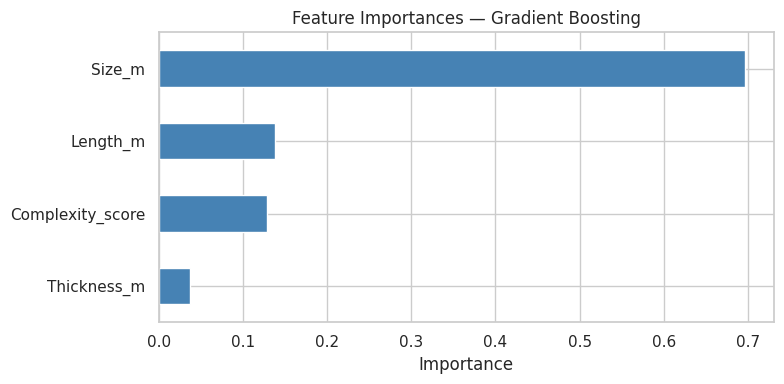

In [19]:
# Built comparison dataframe  for the best model
best = max(results, key=lambda x: x['CV R² mean'])
print(best["Model"])  # check it worked
comparison = pd.DataFrame({
    'Actual_Cost_USD'    : y_test,
    'Predicted_Cost_USD' : best['y_pred'],
})
comparison['Absolute_Error'] = np.abs(comparison['Actual_Cost_USD']
                                      - comparison['Predicted_Cost_USD'])
comparison['Pct_Error (%)']  = (comparison['Absolute_Error']
                                 / comparison['Actual_Cost_USD'] * 100).round(2)

print(f'=== Summary: Actual vs Predicted ({best["Model"]}) ===')
display(comparison.describe().T.style.background_gradient(cmap='YlOrRd_r'))

print('\n=== Worst 10 predictions ===')
display(comparison.nlargest(10, 'Absolute_Error').reset_index(drop=True))

# Feature importance(tree models only)
if hasattr(best['object'], 'feature_importances_'):
    imp = pd.Series(best['object'].feature_importances_,
                    index=FEATURES).sort_values(ascending=True)

    plt.figure(figsize=(8, 4))
    imp.plot(kind='barh', color='steelblue', edgecolor='white')
    plt.title(f'Feature Importances — {best["Model"]}', fontsize=12)
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.savefig('07_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

In [20]:
from google.colab import drive
import shutil
import os

drive.mount('/content/drive')

# Create a folder in Drive for this project
os.makedirs('/content/drive/MyDrive/welding_project', exist_ok=True)

# Copy all your PNGs and CSV to Drive
files_to_save = [
    '01_target_distribution.png',
    '02_correlation_heatmap.png',
    '03_scatter_trends.png',
    '04_actual_vs_predicted.png',
    '06_metric_comparison.png',
    '07_feature_importance.png',
    'welding_pricing_dataset.csv'
]

for file in files_to_save:
    if os.path.exists(file):
        shutil.copy(file, f'/content/drive/MyDrive/welding_project/{file}')

print("Done! Check Google Drive > My Drive > welding_project")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Done! Check Google Drive > My Drive > welding_project


In [ ]:
print(df.columns)

Index(['ID', 'Material', 'Type', 'Shape', 'Size_m', 'Thickness_m', 'Length_m',
       'Price_ZAR', 'Price_per_meter', 'Material_Encoded'],
      dtype='object')


In [ ]:
print(df.columns.tolist())

['ID', 'Material', 'Type', 'Shape', 'Size_m', 'Thickness_m', 'Length_m', 'Price_ZAR', 'Price_per_meter', 'Material_Encoded']
